# EDA
## Students Social Media Addiction

> #### Setup

In [112]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [113]:
data = pd.read_csv("data/Students Social Media Addiction.csv")

> #### Inspektion

In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

>> Student ID är inget som behövs för att träna en modell. Den innehåller unika värden för att säkerställa att det inte finns duplicerad data.
</br></br> 
>> Det gör också att det inte finns en korrekt ordning och det skulle inte gå att prediktera vilket betyder att det skulle vara ivägen för modellen. 

In [115]:
data = data.drop("Student_ID", axis=1)

In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    object 
 2   Academic_Level                705 non-null    object 
 3   Country                       705 non-null    object 
 4   Avg_Daily_Usage_Hours         705 non-null    float64
 5   Most_Used_Platform            705 non-null    object 
 6   Affects_Academic_Performance  705 non-null    object 
 7   Sleep_Hours_Per_Night         705 non-null    float64
 8   Mental_Health_Score           705 non-null    int64  
 9   Relationship_Status           705 non-null    object 
 10  Conflicts_Over_Social_Media   705 non-null    int64  
 11  Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 66.2+ KB


> #### Inspektera kategoriska kolumner

> ##### *Country*

In [117]:
print("Sorted by count:")
count_2 = 0
for country, count in data["Country"].value_counts().items():
  if count == 1:
    count_2 += count
    continue
  print(f"{country}: {count}")
print(f"Other (Got 1 count): {count_2}")

Sorted by count:
India: 53
USA: 40
Canada: 34
France: 27
Mexico: 27
Spain: 27
Turkey: 27
Ireland: 27
Denmark: 27
Switzerland: 27
UK: 22
Japan: 21
Italy: 21
Russia: 21
Bangladesh: 20
Maldives: 19
Sri Lanka: 19
Nepal: 19
Pakistan: 19
China: 16
Poland: 16
Germany: 14
Australia: 14
South Korea: 13
UAE: 8
Singapore: 8
New Zealand: 8
Brazil: 8
Malaysia: 8
Netherlands: 8
Finland: 8
Other (Got 1 count): 79


In [78]:
pivotdata = data[data.groupby('Country')['Country'].transform('count') > 1]
pivot = (
    pivotdata.pivot_table(index="Country", columns="Addicted_Score", aggfunc="size", fill_value=0)
)
print('Count per "Addicted Score" (excluding those who only got 1 count)')
print(pivot)

Count per "Addicted Score" (excluding those who only got 1 count)
Addicted_Score  2   3   4   5   6   7   8   9
Country                                      
Australia       0   0   0  13   0   0   0   1
Bangladesh      0   0   0   0   0  10  10   0
Brazil          0   0   0   0   0   7   1   0
Canada          0   0   0   1   8  25   0   0
China           0   0   0   7   0   9   0   0
Denmark         0   0  19   8   0   0   0   0
Finland         0   0   0   7   0   0   1   0
France          0   0   0  25   0   2   0   0
Germany         1   0  13   0   0   0   0   0
India           0   1   0   0  10   9  25   8
Ireland         0   0   0   0  18   7   1   1
Italy           0   0   1   8   0   6   6   0
Japan           0  12   8   1   0   0   0   0
Malaysia        0   1   0   0   0   7   0   0
Maldives        0   0   0   8   0   1  10   0
Mexico          0   0   0   0   0  18   8   1
Nepal           0   0   0   8   1   0  10   0
Netherlands     0   0   7   0   0   1   0   0
New Zealand   

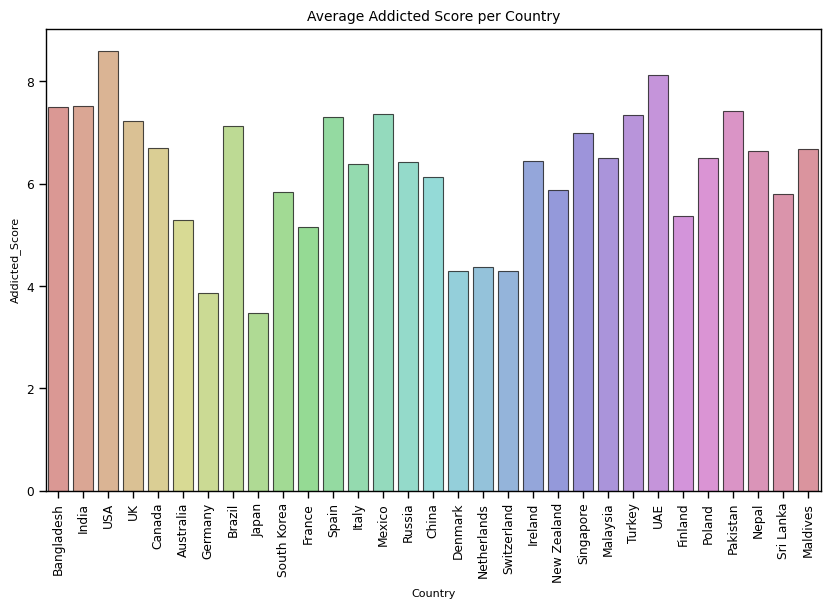

In [91]:
plt.figure(figsize=(10,6))
sns.barplot(x="Country", y="Addicted_Score", data=pivotdata, estimator="mean", alpha=.7, edgecolor="k", hue="Country", palette="hls", legend=False, errorbar=None)
plt.xticks(rotation=90)
plt.title("Average Addicted Score per Country")
plt.show()

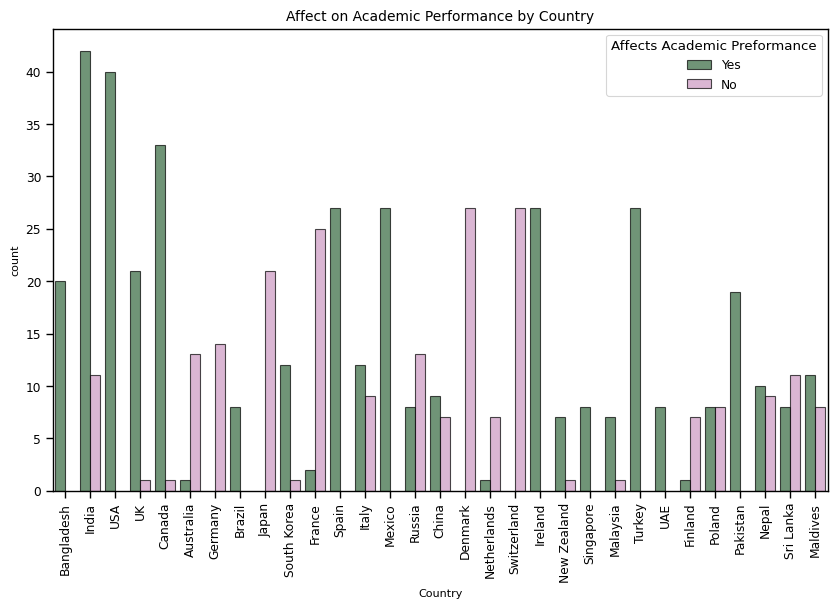

In [105]:
plt.figure(figsize=(10,6))
sns.countplot(data=pivotdata, x="Country", hue="Affects_Academic_Performance", palette="cubehelix", alpha=.7, edgecolor="k")
plt.xticks(rotation=90)
plt.title("Affect on Academic Performance by Country")
plt.legend(title="Affects Academic Preformance")
plt.show()

>> Det finns för lite data för att veta hur mycket fördelningen har med vilket land man kommer ifrån eller om det handlar om vilka som deltog i undersökningen. 
</br></br>
>> Ett annat problem med kolumnen är att det är nominal data. Det betyder att man måste använda *one-hot-encoding* (eller *dummy-variable-encoding* om man har en linjär modell) för att omvandla det till något som modellen förstår. Det skulle skapa aldelese för många dimensioner för något som mest troligt inte påverkar resultatet. 

In [143]:
data = data.drop("Country", axis=1)

In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    object 
 2   Academic_Level                705 non-null    object 
 3   Avg_Daily_Usage_Hours         705 non-null    float64
 4   Most_Used_Platform            705 non-null    object 
 5   Affects_Academic_Performance  705 non-null    object 
 6   Sleep_Hours_Per_Night         705 non-null    float64
 7   Mental_Health_Score           705 non-null    int64  
 8   Relationship_Status           705 non-null    object 
 9   Conflicts_Over_Social_Media   705 non-null    int64  
 10  Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 60.7+ KB


> ##### Most Used Platform

In [118]:
print("Sorted by count:")
for platform, count in data["Most_Used_Platform"].value_counts().items():
  print(f"{platform}: {count}")

Sorted by count:
Instagram: 249
TikTok: 154
Facebook: 123
WhatsApp: 54
Twitter: 30
LinkedIn: 21
WeChat: 15
Snapchat: 13
VKontakte: 12
LINE: 12
KakaoTalk: 12
YouTube: 10


In [119]:
pivot = (
    data.pivot_table(index="Most_Used_Platform", columns="Addicted_Score", aggfunc="size", fill_value=0)
)
print('Count per "Addicted Score"')
print(pivot)

Count per "Addicted Score"
Addicted_Score      2   3   4   5   6   7   8   9
Most_Used_Platform                               
Facebook            0   0  25  50  14  12  19   3
Instagram           0   0  31  46  19  90  33  30
KakaoTalk           0   0   0   0  12   0   0   0
LINE                0  12   0   0   0   0   0   0
LinkedIn            1   3  16   1   0   0   0   0
Snapchat            0   0   0   0   1   6   5   1
TikTok              0   0   1   9  11  55  58  20
Twitter             0   1   9   9   0   7   4   0
VKontakte           0   0   0  12   0   0   0   0
WeChat              0   0   0   7   0   8   0   0
WhatsApp            0   0   0   0   0  29  25   0
YouTube             0   0   1   2   4   2   0   1


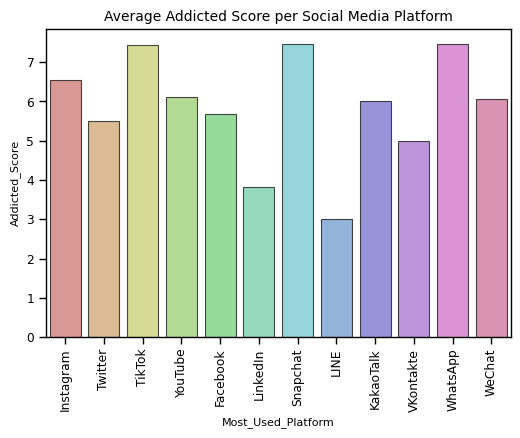

In [132]:
plt.figure(figsize=(6,4))
sns.barplot(x="Most_Used_Platform", y="Addicted_Score", data=data, estimator="mean", alpha=.7, edgecolor="k", hue="Most_Used_Platform", palette="hls", legend=False, errorbar=None)
plt.xticks(rotation=90)
plt.title("Average Addicted Score per Social Media Platform")
plt.show()

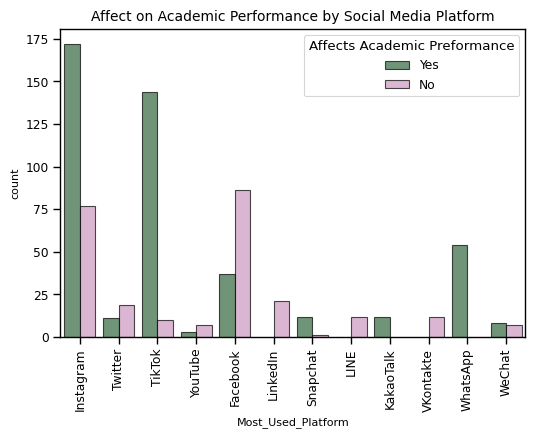

In [133]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x="Most_Used_Platform", hue="Affects_Academic_Performance", palette="cubehelix", alpha=.7, edgecolor="k")
plt.xticks(rotation=90)
plt.title("Affect on Academic Performance by Social Media Platform")
plt.legend(title="Affects Academic Preformance")
plt.show()

>> Det här är en annan kolumn som har nominal data. Man kan se att vissa platformar har större påverkan än andra. 
</br></br>
>> Samt är det en kolumn som bara visar den mest använda platformen för individen men det är vanligt att en person använder flera olika platformar. 
</br></br>
>> En ytterligare observation är att fördelningen är ojämn vilket leder till att det saknas information för att kunna göra en bra bedömning. 

In [145]:
data = data.drop("Most_Used_Platform", axis=1)

In [146]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Gender                        705 non-null    object 
 2   Academic_Level                705 non-null    object 
 3   Avg_Daily_Usage_Hours         705 non-null    float64
 4   Affects_Academic_Performance  705 non-null    object 
 5   Sleep_Hours_Per_Night         705 non-null    float64
 6   Mental_Health_Score           705 non-null    int64  
 7   Relationship_Status           705 non-null    object 
 8   Conflicts_Over_Social_Media   705 non-null    int64  
 9   Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 55.2+ KB


> ##### Gender

In [125]:
print("Sorted by count:")
for gender, count in data["Gender"].value_counts().items():
  print(f"{gender}: {count}")

Sorted by count:
Female: 353
Male: 352


In [126]:
pivot = (
    data.pivot_table(index="Gender", columns="Addicted_Score", aggfunc="size", fill_value=0)
)
print('Count per "Gender"')
print(pivot)

Count per "Gender"
Addicted_Score  2   3   4   5   6    7   8   9
Gender                                        
Female          0  12  38  72  30   83  71  47
Male            1   4  45  64  31  126  73   8


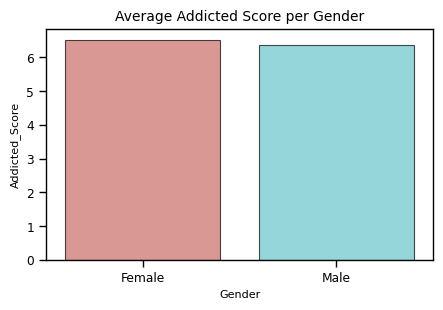

In [129]:
plt.figure(figsize=(5,3))
sns.barplot(x="Gender", y="Addicted_Score", data=data, estimator="mean", alpha=.7, edgecolor="k", hue="Gender", palette="hls", legend=False, errorbar=None)
plt.title("Average Addicted Score per Gender")
plt.show()

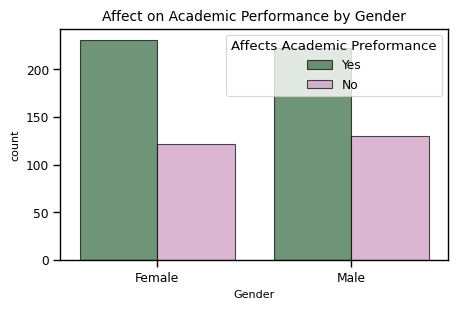

In [130]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="Gender", hue="Affects_Academic_Performance", palette="cubehelix", alpha=.7, edgecolor="k")
plt.title("Affect on Academic Performance by Gender")
plt.legend(title="Affects Academic Preformance")
plt.show()

>> Fördelningen mellan män och kvinnor är väldigt jämn och har mest troligt ingen direkt påverkan resultatet. 

In [147]:
data = data.drop("Gender", axis=1)

In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           705 non-null    int64  
 1   Academic_Level                705 non-null    object 
 2   Avg_Daily_Usage_Hours         705 non-null    float64
 3   Affects_Academic_Performance  705 non-null    object 
 4   Sleep_Hours_Per_Night         705 non-null    float64
 5   Mental_Health_Score           705 non-null    int64  
 6   Relationship_Status           705 non-null    object 
 7   Conflicts_Over_Social_Media   705 non-null    int64  
 8   Addicted_Score                705 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 49.7+ KB


> ##### Relationship Status

In [134]:
print("Sorted by count:")
for status, count in data["Relationship_Status"].value_counts().items():
  print(f"{status}: {count}")

Sorted by count:
Single: 384
In Relationship: 289
Complicated: 32


In [135]:
pivot = (
    data.pivot_table(index="Relationship_Status", columns="Addicted_Score", aggfunc="size", fill_value=0)
)
print('Count per "Relationship Status"')
print(pivot)

Count per "Relationship Status"
Addicted_Score       2   3   4   5   6    7   8   9
Relationship_Status                                
Complicated          0   0   4   1   3   12   6   6
In Relationship      0   1  34  88  24   51  66  25
Single               1  15  45  47  34  146  72  24


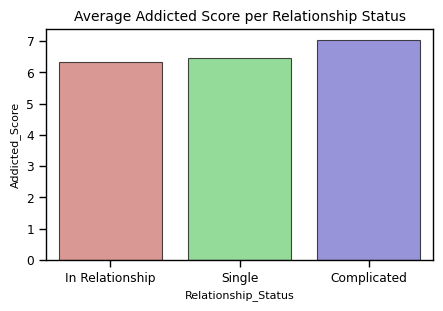

In [136]:
plt.figure(figsize=(5,3))
sns.barplot(x="Relationship_Status", y="Addicted_Score", data=data, estimator="mean", alpha=.7, edgecolor="k", hue="Relationship_Status", palette="hls", legend=False, errorbar=None)
plt.title("Average Addicted Score per Relationship Status")
plt.show()

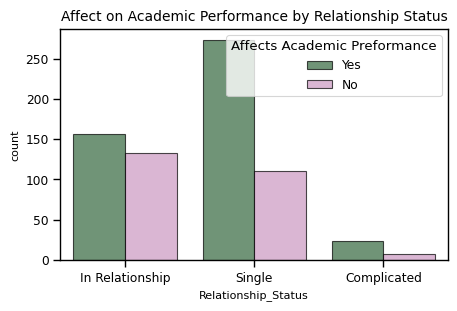

In [137]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="Relationship_Status", hue="Affects_Academic_Performance", palette="cubehelix", alpha=.7, edgecolor="k")
plt.title("Affect on Academic Performance by Relationship Status")
plt.legend(title="Affects Academic Preformance")
plt.show()

>> Svårt att säga hur mycket det påverkar. Det må vara nominal data men det är få kolumner. Måste göra en övervägning om jag tror det är bra att ha med. 

In [ ]:
# Do one-hot-encoding
# Part of ML preprocessing

> ##### Academic Level

In [138]:
for level, count in data["Academic_Level"].value_counts().items():
  print(f"{level}: {count}")

Undergraduate: 353
Graduate: 325
High School: 27


In [139]:
pivot = (
    data.pivot_table(index="Age", columns="Academic_Level", aggfunc="size", fill_value=0)
)
print(pivot)

Academic_Level  Graduate  High School  Undergraduate
Age                                                 
18                     0           14              0
19                     0           11            152
20                     0            2            163
21                   118            0             38
22                   147            0              0
23                    34            0              0
24                    26            0              0


In [140]:
pivot = (
    data.pivot_table(index="Academic_Level", columns="Addicted_Score", aggfunc="size", fill_value=0)
)
print('Count per "Academic Level"')
print(pivot)

Count per "Academic Level"
Addicted_Score  2   3   4   5   6    7   8   9
Academic_Level                                
Graduate        1   4  52  59  25  116  62   6
High School     0   0   1   1   0    0  17   8
Undergraduate   0  12  30  76  36   93  65  41


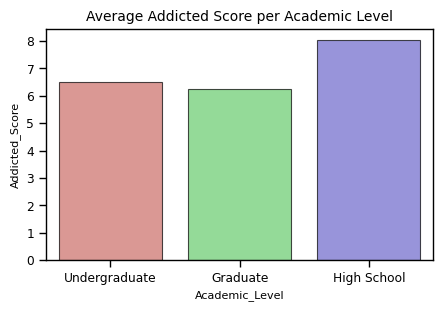

In [141]:
plt.figure(figsize=(5,3))
sns.barplot(x="Academic_Level", y="Addicted_Score", data=data, estimator="mean", alpha=.7, edgecolor="k", hue="Academic_Level", palette="hls", legend=False, errorbar=None)
plt.title("Average Addicted Score per Academic Level")
plt.show()

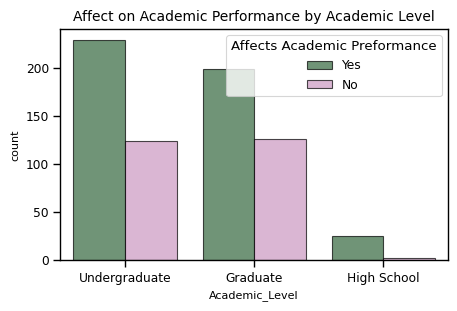

In [142]:
plt.figure(figsize=(5,3))
sns.countplot(data=data, x="Academic_Level", hue="Affects_Academic_Performance", palette="cubehelix", alpha=.7, edgecolor="k")
plt.title("Affect on Academic Performance by Academic Level")
plt.legend(title="Affects Academic Preformance")
plt.show()

>> Svårt att avgöra hur mycket det påverkar. Datan är ordinal och lätt att omvandla till *Categorcal*. 

In [149]:
# Convert to categorical
data["Academic_Level"] = pd.Categorical(data.Academic_Level, categories=["High School", "Undergraduate", "Graduate"], ordered=True)

In [152]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Age                           705 non-null    int64   
 1   Academic_Level                705 non-null    category
 2   Avg_Daily_Usage_Hours         705 non-null    float64 
 3   Affects_Academic_Performance  705 non-null    object  
 4   Sleep_Hours_Per_Night         705 non-null    float64 
 5   Mental_Health_Score           705 non-null    int64   
 6   Relationship_Status           705 non-null    object  
 7   Conflicts_Over_Social_Media   705 non-null    int64   
 8   Addicted_Score                705 non-null    int64   
dtypes: category(1), float64(2), int64(4), object(2)
memory usage: 45.0+ KB


> ##### Inspektera korrelation

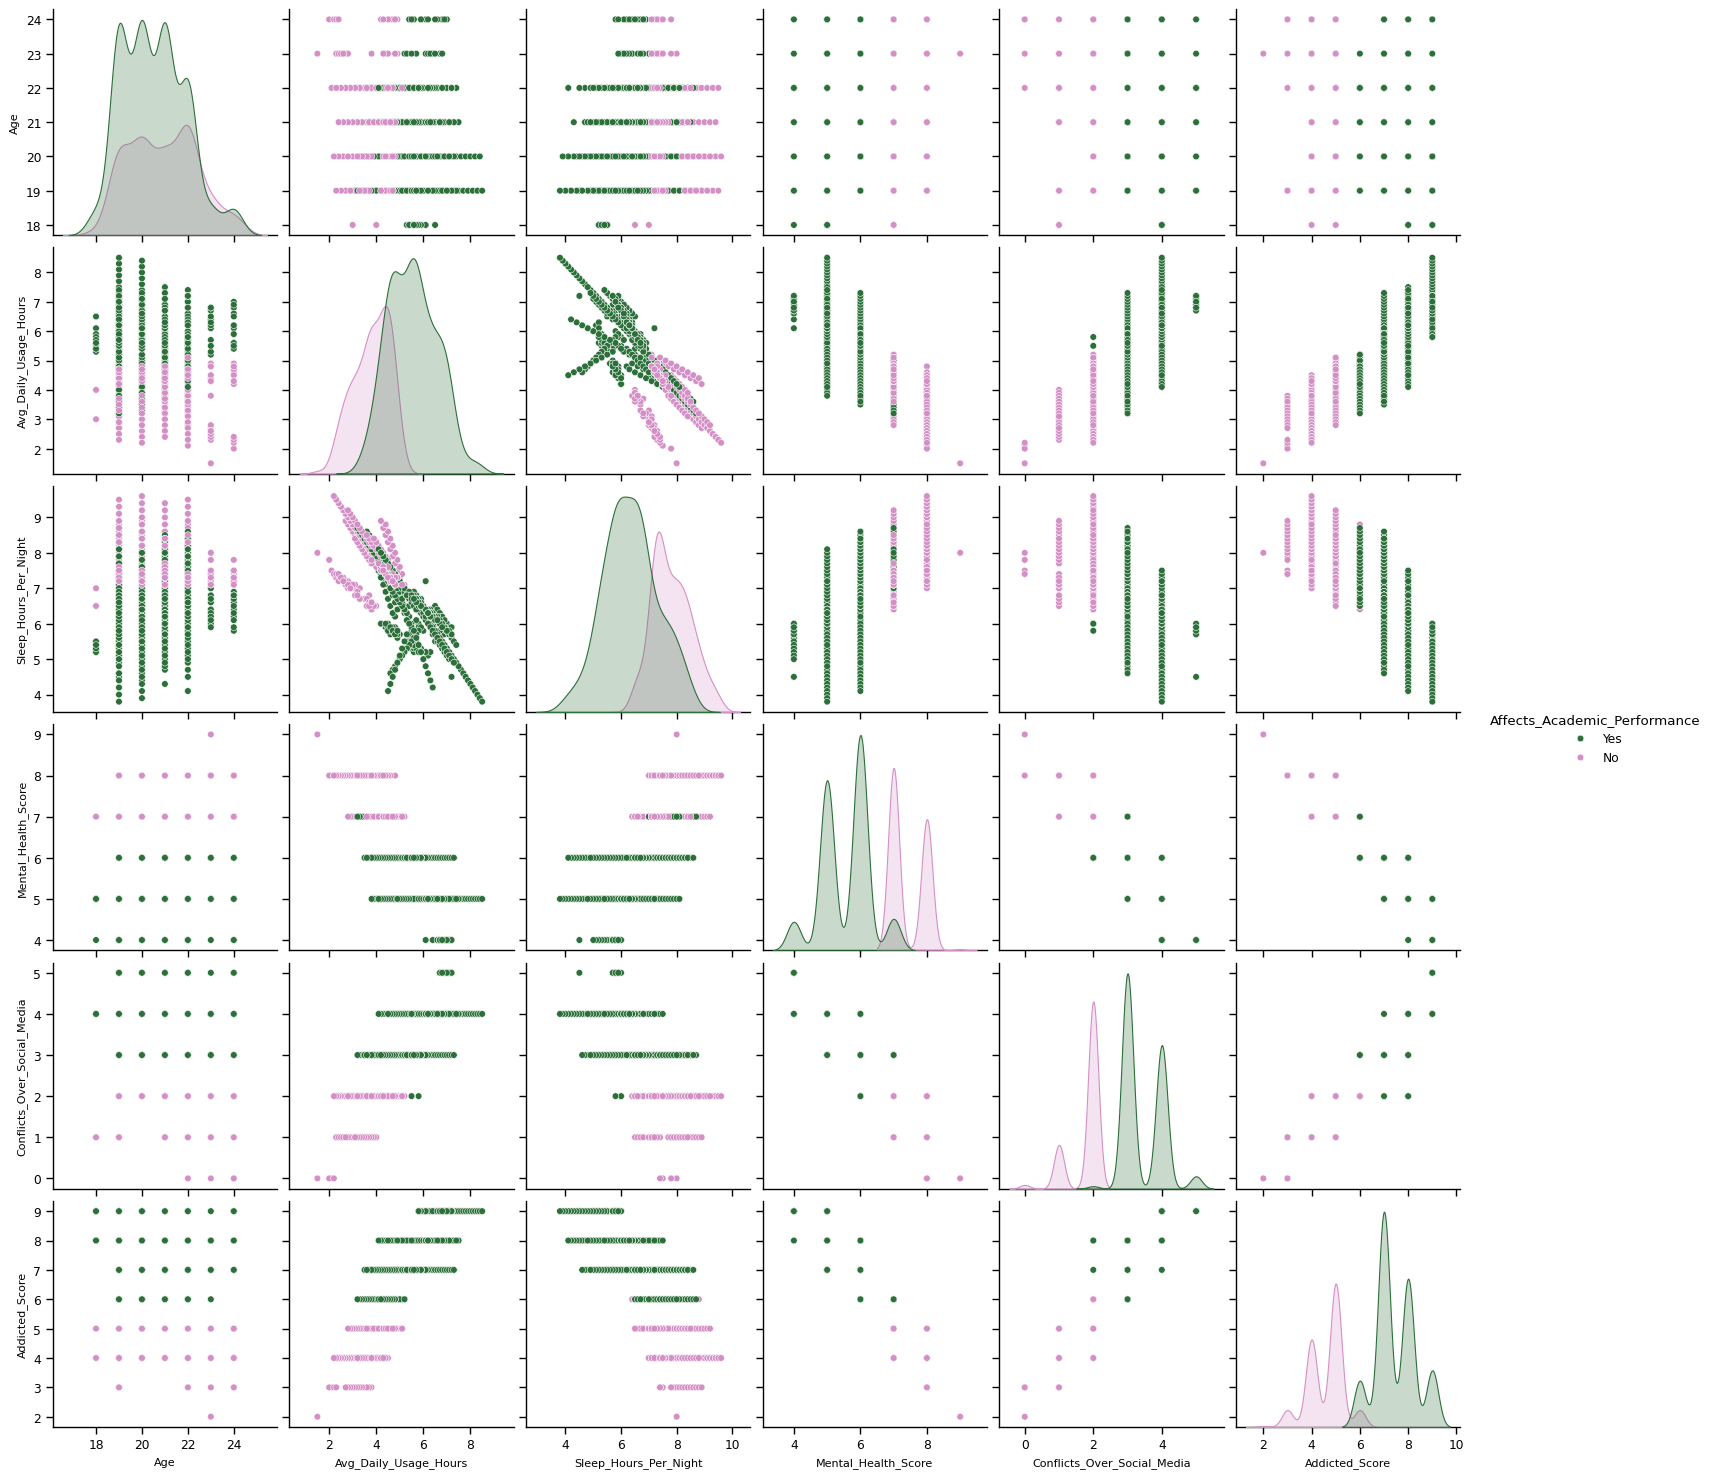

In [153]:
sns.pairplot(data=data, hue="Affects_Academic_Performance", palette="cubehelix")

>> Med en *pairplot* för varje par av numeriska kolumner ser vi att ålder har liten påverkan och att övriga kolumner har många korrelationer med varandra. Genom att sätta *hue* till kategorin för akademisk påverkan ser man också tydligt var gränsen finns för negativ påverkan. 

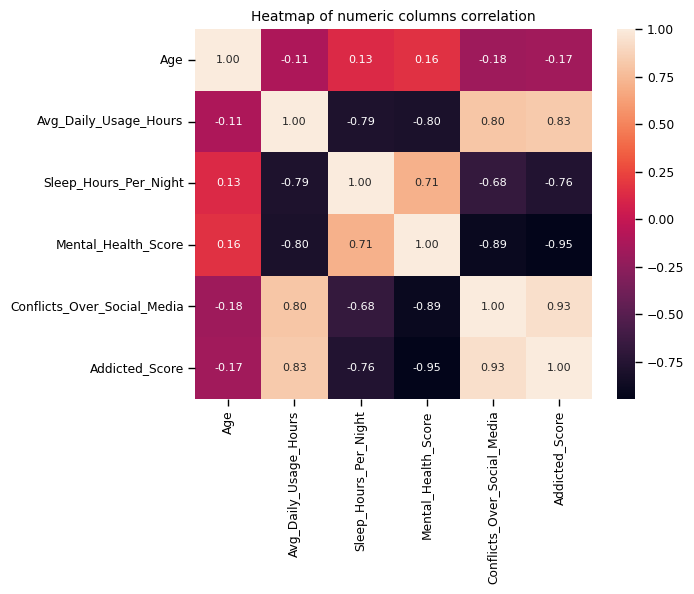

In [68]:
numeric_columns = data.select_dtypes(exclude=object)
corr = numeric_columns.corr()

ax = sns.heatmap(corr, annot=True, fmt=".2f")
ax.set_title("Heatmap of numeric columns correlation")
sns.set_context("paper", rc={"font.size":8, "axes.titlesize": 10, "axes.labelsize": 8})

>> Min *heatmap* över de numeriska kolumnernas korrelation målar samma bild. 

In [154]:
data = data.drop("Age", axis=1)

In [155]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Academic_Level                705 non-null    category
 1   Avg_Daily_Usage_Hours         705 non-null    float64 
 2   Affects_Academic_Performance  705 non-null    object  
 3   Sleep_Hours_Per_Night         705 non-null    float64 
 4   Mental_Health_Score           705 non-null    int64   
 5   Relationship_Status           705 non-null    object  
 6   Conflicts_Over_Social_Media   705 non-null    int64   
 7   Addicted_Score                705 non-null    int64   
dtypes: category(1), float64(2), int64(3), object(2)
memory usage: 39.5+ KB


> ##### Inspektera fördelning

In [19]:
print("Sorted by count:")
for score, count in data["Addicted_Score"].value_counts().items():
  print(f"{score}: {count}")
print()
print("Sorted by score:")
for score, count in data["Addicted_Score"].value_counts(sort=False).sort_index().items():
  print(f"{score}: {count}")

Sorted by count:
7: 209
8: 144
5: 136
4: 83
6: 61
9: 55
3: 16
2: 1

Sorted by score:
2: 1
3: 16
4: 83
5: 136
6: 61
7: 209
8: 144
9: 55
